## Punto 1 — Análisis exploratorio y limpieza de datos

**Qué se hizo y por qué.** Usamos el dataset *Medical Cost Personal* de Kaggle (`insurance.csv`): 1.338 personas aseguradas en EE. UU. con 7 columnas: edad, sexo, índice de masa corporal (BMI), número de hijos, si fuma, región y gasto médico anual (`charges`). Cumple lo pedido: más de 500 ejemplos, dos predictoras continuas (`age`, `bmi`) y una variable objetivo continua (`charges`).

**Recorrido del código**

1. **Librerías:** pandas para manejar tablas, numpy para cálculos, matplotlib y seaborn para gráficos.
2. **Carga y primera mirada:** `read_csv` lee el archivo, `head()` muestra las primeras filas e `info()` confirma 1.338 filas, tipos de datos correctos y ninguna columna vacía.
3. **Selección de variables:** `X = df[['age', 'bmi']]` son las predictoras e `y = df['charges']` es la variable objetivo.
4. **Gráficos de dispersión:** edad vs. gasto y BMI vs. gasto, coloreados según `smoker`. El gasto sube con la edad, pero lo que más se nota es que los fumadores forman un grupo aparte con gastos mucho mayores (promedio ≈ 32.050 frente a ≈ 8.434 de los no fumadores).
5. **Limpieza:** `isnull().sum()` confirma que no hay valores nulos y `drop_duplicates()` elimina 1 fila repetida, con lo que quedan 1.337.
6. **Estadísticas descriptivas:** `describe()` muestra un gasto medio de ≈ 13.279, una desviación de ≈ 12.110 y un máximo de ≈ 63.770. La variable es muy asimétrica: hay pocos casos muy caros.

**Conclusiones para el modelo**

- Los datos están limpios y no hace falta rellenar valores.
- La relación de `age` y `bmi` con `charges` es positiva pero débil (correlación ≈ 0,30 y ≈ 0,20). La mayor parte de la variación se explica por el tabaquismo, que no es una de las predictoras, así que se espera un R² bajo en el punto 3.
- Detalle: `X` e `y` se definen antes de `drop_duplicates()`, por lo que el modelo usa las 1.338 filas. Con un solo duplicado el efecto es mínimo, pero lo ideal sería definirlas después de limpiar.

Primeras Filas
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Informacion del Dataset
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None
Total de Filas: 1338 | Total de Columnas: 7


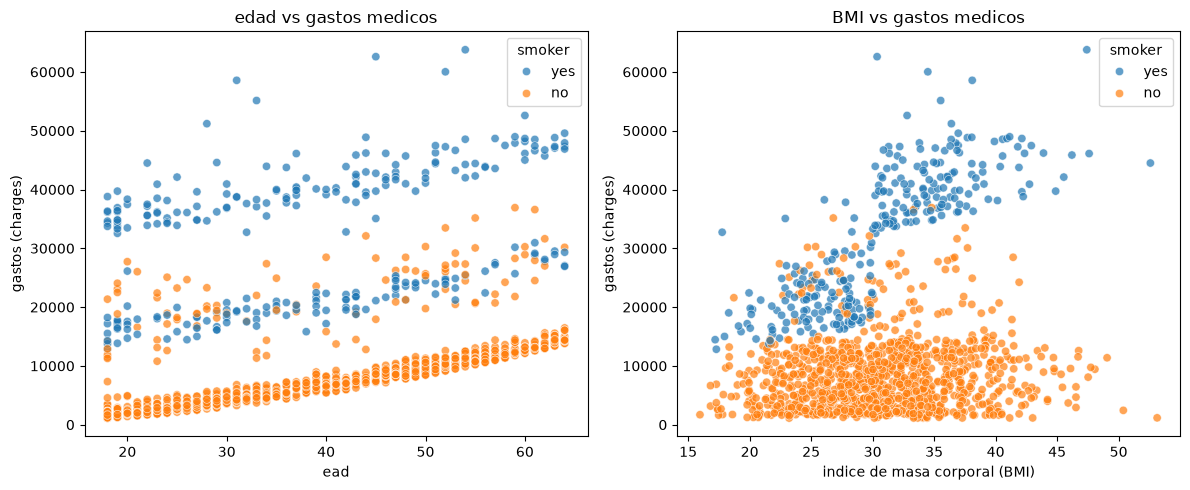

Valores nulos por Columna
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Estadisticas descriptivas
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("insurance.csv")
print("Primeras Filas")
print(df.head())

print("Informacion del Dataset")
print(df.info())
print(f"Total de Filas: {df.shape[0]} | Total de Columnas: {df.shape[1]}")

X = df[['age', 'bmi']]
y = df['charges']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7)
plt.title('edad vs gastos medicos')
plt.xlabel('ead')
plt.ylabel('gastos (charges)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7)
plt.title('BMI vs gastos medicos')
plt.xlabel('indice de masa corporal (BMI)')
plt.ylabel('gastos (charges)')

plt.tight_layout()
plt.show()


print("Valores nulos por Columna")
print(df.isnull().sum())

df = df.drop_duplicates()

print("Estadisticas descriptivas")
print(df.describe())

## Punto 2 — Clase `MyLinearRegression` (ecuación normal)

**La lógica.** La regresión lineal busca una "receta" de la forma ŷ = θ₀ + θ₁·x₁ + θ₂·x₂: un valor base más lo que aporta cada variable. Los mejores θ son los que minimizan la suma de los errores al cuadrado entre lo real y lo predicho. Al escribir ese error con matrices, derivarlo e igualarlo a cero se obtiene una fórmula cerrada, la ecuación normal:

$$\theta = (X^T X)^{-1} X^T y$$

No hay iteraciones ni tasa de aprendizaje. El resultado sale en un solo cálculo y es el mínimo global, porque la función de error es convexa (tiene forma de tazón).

**El código, método por método**

- `__init__`: crea el modelo con `b_` (coeficientes θ₁…θₙ) e `intercept_` (θ₀) vacíos, con los mismos nombres que usa sklearn.
- `_to_2d` y `_add_bias_column`: preparan X. La primera asegura que X sea una tabla. La segunda le agrega una columna de unos, que es lo que permite calcular θ₀ junto con los demás parámetros.
- `fit(X, y)`: verifica que X e y tengan la misma cantidad de filas, arma la matriz con la columna de unos y aplica la ecuación tal cual. `X_b.T @ X_b` es XᵀX, `X_b.T @ y` es Xᵀy, `np.linalg.inv` calcula la inversa y el producto final da θ. Luego guarda `theta[0]` en `intercept_` y el resto en `b_`. Si XᵀX no se puede invertir (variables colineales), usa la pseudo-inversa `pinv` en lugar de fallar.
- `predict(X)`: comprueba que el modelo esté entrenado y que X tenga el número correcto de variables, y aplica la receta `intercept_ + X @ b_`.
- `mse(y_true, y_pred)`: promedio de los errores al cuadrado. Cuanto más bajo, mejor. Está en unidades de y al cuadrado.
- `r2_score(y_true, y_pred)`: 1 − (error del modelo / variación total de y). Es la proporción de la variación que explica el modelo: 1 es un ajuste perfecto y 0 equivale a predecir siempre el promedio. Si y es constante, evita dividir por cero.

`mse` y `r2_score` son métodos estáticos porque no usan los parámetros aprendidos, solo comparan dos listas de valores.

**Ejemplo de prueba.** Después de la clase, un ejemplo pequeño con 4 casos generados con la receta y = 3 + 2·x₁ + 1·x₂. El modelo debe recuperar exactamente θ₀ = 3, θ₁ = 2 y θ₂ = 1, con MSE ≈ 0 y R² = 1, y predecir 17 para un caso nuevo con x₁ = 5 y x₂ = 4 (3 + 10 + 4). Así se comprueba que la clase funciona antes de usarla con el dataset real.

In [2]:
class MyLinearRegression:

    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.b_ = None
        self.intercept_ = None

    @staticmethod
    def _to_2d(X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return X

    def _add_bias_column(self, X):
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    def fit(self, X, y):
        X = self._to_2d(X)
        y = np.asarray(y, dtype=float).ravel()

        if X.shape[0] != y.shape[0]:
            raise ValueError(
                f"X tiene {X.shape[0]} filas pero y tiene {y.shape[0]} valores."
            )

        X_b = self._add_bias_column(X) if self.fit_intercept else X

        XtX = X_b.T @ X_b
        Xty = X_b.T @ y
        try:
            XtX_inv = np.linalg.inv(XtX)
        except np.linalg.LinAlgError:
            XtX_inv = np.linalg.pinv(XtX)
        theta = XtX_inv @ Xty

        if self.fit_intercept:
            self.intercept_ = theta[0]
            self.b_ = theta[1:]
        else:
            self.intercept_ = 0.0
            self.b_ = theta
        return self

    def predict(self, X):
        if self.b_ is None:
            raise RuntimeError("El modelo no está entrenado. Llama primero a fit().")
        X = self._to_2d(X)
        if X.shape[1] != self.b_.shape[0]:
            raise ValueError(
                f"Se esperaban {self.b_.shape[0]} variables y se recibieron {X.shape[1]}."
            )
        return self.intercept_ + X @ self.b_

    @staticmethod
    def mse(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=float).ravel()
        y_pred = np.asarray(y_pred, dtype=float).ravel()
        return np.mean((y_true - y_pred) ** 2)

    @staticmethod
    def r2_score(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=float).ravel()
        y_pred = np.asarray(y_pred, dtype=float).ravel()
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - y_true.mean()) ** 2)
        if ss_tot == 0:
            return 1.0 if ss_res == 0 else 0.0
        return 1 - ss_res / ss_tot

In [3]:
X_ejemplo = np.array([[1, 1],
                      [2, 1],
                      [3, 2],
                      [4, 3]])
y_ejemplo = np.array([6, 8, 11, 14])

modelo_ejemplo = MyLinearRegression()
modelo_ejemplo.fit(X_ejemplo, y_ejemplo)
pred_ejemplo = modelo_ejemplo.predict(X_ejemplo)

print("Ejemplo: datos generados con y = 3 + 2·x1 + 1·x2")
print(f"Intercepto (theta_0): {modelo_ejemplo.intercept_:.4f}")
print(f"Coeficientes (theta_1, theta_2): {modelo_ejemplo.b_}")
print(f"Predicciones: {pred_ejemplo}")
print(f"Valores reales: {y_ejemplo}")
print(f"MSE: {modelo_ejemplo.mse(y_ejemplo, pred_ejemplo):.4f}")
print(f"R²: {modelo_ejemplo.r2_score(y_ejemplo, pred_ejemplo):.4f}")
print(f"Predicción para un caso nuevo (x1=5, x2=4): {modelo_ejemplo.predict([[5, 4]])[0]:.4f}")

Ejemplo: datos generados con y = 3 + 2·x1 + 1·x2
Intercepto (theta_0): 3.0000
Coeficientes (theta_1, theta_2): [2. 1.]
Predicciones: [ 6.  8. 11. 14.]
Valores reales: [ 6  8 11 14]
MSE: 0.0000
R²: 1.0000
Predicción para un caso nuevo (x1=5, x2=4): 17.0000


## Punto 3 — Entrenamiento y comparación con sklearn

**Qué se hizo.** Se entrenan dos modelos con exactamente los mismos datos (`X` = edad y BMI, `y` = gastos): primero `LinearRegression` de sklearn y luego nuestra clase `MyLinearRegression`. Después se comparan sus parámetros y sus métricas.

**Recorrido del código**

1. **sklearn:** se crea `LinearRegression()`, se entrena con `fit(X, y)`, se predice con `predict(X)` y se calculan `mean_squared_error` y `r2_score` de `sklearn.metrics`.
2. **Nuestra clase:** se repiten los mismos pasos con `MyLinearRegression`, usando sus propios métodos `mse` y `r2_score`.
3. **Comparación:** una tabla pone lado a lado el intercepto, los coeficientes, el MSE y el R² de ambos modelos, junto con su diferencia, y `np.allclose` / `np.isclose` verifican que coincidan.

**Resultados**

| | sklearn | MyLinearRegression |
|---|---|---|
| Intercepto θ₀ | −6.424,80 | −6.424,80 |
| Coeficiente edad θ₁ | 241,93 | 241,93 |
| Coeficiente BMI θ₂ | 332,97 | 332,97 |
| MSE | 129.370.388,91 | 129.370.388,91 |
| R² | 0,1172 | 0,1172 |

Las dos implementaciones dan los mismos valores. Es lo esperado, porque sklearn resuelve el mismo problema de mínimos cuadrados, y confirma que nuestra clase está bien implementada.

**Interpretación**

- Cada año de edad suma ≈ 242 al gasto anual y cada punto de BMI suma ≈ 333, si la otra variable se mantiene fija.
- El intercepto negativo no tiene sentido práctico, porque nadie tiene edad 0 y BMI 0. Solo sirve para ubicar el plano.
- La raíz del MSE da un error típico de ≈ 11.374, casi tan grande como el gasto promedio (≈ 13.279).
- R² = 0,117: el modelo explica solo el 11,7 % de la variación. Ya se vio en el punto 1 que el factor que más pesa es si la persona fuma, y no está en el modelo. Además, la relación no es lineal, porque los fumadores forman un grupo separado. Es un caso de alto sesgo (underfitting).
- Estas métricas se calcularon sobre los mismos datos de entrenamiento. Para evaluar el modelo de verdad habría que separar un conjunto de prueba (pregunta 4).

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sklearn_model = LinearRegression()
sklearn_model.fit(X, y)

y_pred_sklearn = sklearn_model.predict(X)

mse_sklearn = mean_squared_error(y, y_pred_sklearn)
r2_sklearn = r2_score(y, y_pred_sklearn)

print("Resultados modelo sklearn")
print(f"Intercepto (theta_0): {sklearn_model.intercept_:.4f}")
print(f"Coeficientes (theta_1, theta_2): {sklearn_model.coef_}")
print(f"Error Cuadrático Medio (MSE): {mse_sklearn:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_sklearn:.4f}")

Resultados modelo sklearn
Intercepto (theta_0): -6424.8046
Coeficientes (theta_1, theta_2): [241.9307779  332.96509081]
Error Cuadrático Medio (MSE): 129370388.9119
Coeficiente de Determinación (R²): 0.1172


In [5]:
my_model = MyLinearRegression()
my_model.fit(X, y)

y_pred_mio = my_model.predict(X)

mse_mio = my_model.mse(y, y_pred_mio)
r2_mio = my_model.r2_score(y, y_pred_mio)

print("Resultados modelo MyLinearRegression")
print(f"Intercepto (theta_0): {my_model.intercept_:.4f}")
print(f"Coeficientes (theta_1, theta_2): {my_model.b_}")
print(f"Error Cuadrático Medio (MSE): {mse_mio:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_mio:.4f}")

comparacion = pd.DataFrame(
    {
        "sklearn": [sklearn_model.intercept_, *sklearn_model.coef_, mse_sklearn, r2_sklearn],
        "MyLinearRegression": [my_model.intercept_, *my_model.b_, mse_mio, r2_mio],
    },
    index=["Intercepto", "Coef. age", "Coef. bmi", "MSE", "R²"],
)
comparacion["Diferencia"] = (comparacion["sklearn"] - comparacion["MyLinearRegression"]).abs()

print("\nComparación entre implementaciones")
print(comparacion.to_string(float_format=lambda v: f"{v:,.4f}"))

parametros_iguales = np.isclose(sklearn_model.intercept_, my_model.intercept_) and np.allclose(sklearn_model.coef_, my_model.b_)
metricas_iguales = np.isclose(mse_sklearn, mse_mio) and np.isclose(r2_sklearn, r2_mio)
print(f"\n¿Los parámetros coinciden? {parametros_iguales}")
print(f"¿Las métricas coinciden? {metricas_iguales}")

Resultados modelo MyLinearRegression
Intercepto (theta_0): -6424.8046
Coeficientes (theta_1, theta_2): [241.9307779  332.96509081]
Error Cuadrático Medio (MSE): 129370388.9119
Coeficiente de Determinación (R²): 0.1172

Comparación entre implementaciones
                    sklearn  MyLinearRegression  Diferencia
Intercepto      -6,424.8046         -6,424.8046      0.0000
Coef. age          241.9308            241.9308      0.0000
Coef. bmi          332.9651            332.9651      0.0000
MSE        129,370,388.9119    129,370,388.9119      0.0000
R²                   0.1172              0.1172      0.0000

¿Los parámetros coinciden? True
¿Las métricas coinciden? True


## Punto 4 — Preguntas de análisis conceptual

### 4.1 Partición de datos y validación

**Por qué evaluar con datos de prueba.** El objetivo del modelo es predecir casos que nunca vio. Si se evalúa con los mismos datos usados en `fit`, las métricas miden qué tan bien se ajustó a esos datos, no qué tan bien generaliza. Un conjunto de prueba separado simula datos nuevos.

**Riesgo de reportar solo métricas de entrenamiento.** Son optimistas. Un modelo demasiado complejo puede tener un error casi nulo en entrenamiento porque memorizó el ruido, y aun así fallar con datos nuevos. Sin un conjunto de prueba no hay forma de detectarlo.

**Relación con el dilema sesgo-varianza**

- **Alto sesgo (underfitting):** el modelo es demasiado simple. El error es alto tanto en entrenamiento como en prueba.
- **Alta varianza (overfitting):** el modelo se ajusta al ruido. El error es bajo en entrenamiento pero alto en prueba.

Solo comparando los dos conjuntos se sabe de qué lado está el modelo. La celda siguiente separa los datos limpios en 80 % para entrenar y 20 % para probar, y evalúa nuestra clase en ambos.

In [6]:
from sklearn.model_selection import train_test_split

X_full = df[["age", "bmi"]].values
y_full = df["charges"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

modelo = MyLinearRegression().fit(X_train, y_train)
pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

resultados = pd.DataFrame(
    {
        "MSE": [modelo.mse(y_train, pred_train), modelo.mse(y_test, pred_test)],
        "R²": [modelo.r2_score(y_train, pred_train), modelo.r2_score(y_test, pred_test)],
    },
    index=[f"Entrenamiento ({len(y_train)} filas)", f"Prueba ({len(y_test)} filas)"],
)
print(resultados.to_string(float_format=lambda v: f"{v:,.4f}"))

                                        MSE     R²
Entrenamiento (1069 filas) 122,582,276.5644 0.1047
Prueba (268 filas)         157,746,498.4693 0.1415


### 4.2 Diagnóstico de sesgo y varianza

**Resultados** (partición 80/20, `random_state=42`, modelo con `age` y `bmi`):

| Conjunto | MSE | R² |
|---|---|---|
| Entrenamiento (1.069 filas) | 122.582.277 | 0,105 |
| Prueba (268 filas) | 157.746.498 | 0,142 |

**Diagnóstico: alto sesgo (underfitting).**

- **R² bajo en ambos conjuntos.** El modelo explica solo entre el 10 % y el 14 % de la variación, incluso en los datos con los que aprendió.
- **Sin brecha entre entrenamiento y prueba.** Con alta varianza, el entrenamiento sería mucho mejor que la prueba, y aquí no pasa. El R² de prueba incluso es algo mayor, por efecto de la partición al azar. El MSE de prueba es mayor porque ese 20 % tiene gastos más dispersos, y R² lo compensa al medir respecto de esa variación.
- **Complejidad del modelo frente al dataset.** Un modelo lineal con 2 variables tiene solo 3 parámetros para 1.069 ejemplos, así que no puede memorizar ruido. El problema es el contrario: el gasto médico no depende linealmente de la edad y el BMI. Depende sobre todo de si la persona fuma, que separa los datos en grupos distintos.
- **Comprobación.** Al agregar `smoker` (0/1) como tercera variable, el R² sube a ≈ 0,73 en entrenamiento y ≈ 0,80 en prueba (celda siguiente). El modelo original no fallaba por sobreajuste, sino por falta de información y de capacidad para representar los datos.

In [7]:
X_smoker = df[["age", "bmi"]].assign(smoker=(df["smoker"] == "yes").astype(int)).values

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_smoker, y_full, test_size=0.2, random_state=42
)

modelo_smoker = MyLinearRegression().fit(Xs_train, ys_train)

print("Modelo con age, bmi y smoker")
print(f"R² entrenamiento: {modelo_smoker.r2_score(ys_train, modelo_smoker.predict(Xs_train)):.4f}")
print(f"R² prueba:        {modelo_smoker.r2_score(ys_test, modelo_smoker.predict(Xs_test)):.4f}")

Modelo con age, bmi y smoker
R² entrenamiento: 0.7262
R² prueba:        0.8050
